# Transfer Learning for Skin Lesion Classification

In this notebook, we will build a skin lesion classification model using Transfer Learning.

Transfer Learning means using a deep learning model that has already been trained on a large dataset and adapting it for a new task.

For this project, we will use MobileNetV2 with the HAM10000 skin lesion dataset.

## Learning Objectives

- Load HAM10000 metadata and images
- Prepare skin lesion images
- Encode diagnosis labels
- Use MobileNetV2 as a pre-trained feature extractor
- Build a custom classification head
- Train and evaluate a transfer learning model
- Understand why transfer learning is useful in Medical AI

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

2026-06-27 17:29:40.268041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782581380.498069      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782581380.566782      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782581381.079141      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782581381.079191      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782581381.079194      16 computation_placer.cc:177] computation placer alr

## Step 1: Load HAM10000 Metadata

The HAM10000 metadata file contains information about each dermoscopic image.

Important columns include:

- image_id: image file name
- dx: diagnosis label
- age: patient age
- sex: patient sex
- localization: body location of the lesion

We will use the image ID and diagnosis label for classification.

In [2]:
dataset_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path = os.path.join(
    dataset_path,
    "HAM10000_metadata.csv"
)

df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## Step 2: Define Image Folders

The HAM10000 images are stored in two separate folders:

- HAM10000_images_part_1
- HAM10000_images_part_2

We need to search both folders to find the correct image path for each image ID.

In [3]:
image_folders = [
    os.path.join(dataset_path, "HAM10000_images_part_1"),
    os.path.join(dataset_path, "HAM10000_images_part_2")
]

for folder in image_folders:
    print(folder)

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2


## Step 3: Create Image Path Function

The metadata stores image IDs without the `.jpg` extension.

This function adds `.jpg`, searches both image folders, and returns the correct image path.

In [4]:
def find_image_path(image_id):
    filename = image_id + ".jpg"

    for folder in image_folders:
        path = os.path.join(folder, filename)

        if os.path.exists(path):
            return path

    return None


df["image_path"] = df["image_id"].apply(find_image_path)

df[["image_id", "dx", "image_path"]].head()

,image_id,dx,image_path
0,ISIC_0027419,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,bkl,/kaggle/input/datasets/kmader/skin-cancer-mnis...


## Step 4: Check Missing Image Paths

Before training, we should confirm that all image paths were found correctly.

If missing paths exist, those rows should be removed.

In [5]:
missing_paths = df["image_path"].isnull().sum()

print("Missing Image Paths:", missing_paths)

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Dataset Shape After Removing Missing Paths:", df.shape)

Missing Image Paths: 0
Dataset Shape After Removing Missing Paths: (10015, 8)


## Step 5: Select a Smaller Sample

HAM10000 contains many images.

For beginner practice and faster Kaggle training, we will use a smaller sample.

This makes the notebook easier to run while still demonstrating the full transfer learning workflow.

In [6]:
sample_size = 2000

sample_df = df.sample(
    n=sample_size,
    random_state=42
).reset_index(drop=True)

print("Sample Shape:", sample_df.shape)

sample_df["dx"].value_counts()

Sample Shape: (2000, 8)


dx
nv       1337
bkl       228
mel       224
bcc        93
akiec      69
df         28
vasc       21
Name: count, dtype: int64

## Step 6: Load and Preprocess Images

MobileNetV2 expects images of size:

224 × 224 × 3

For each image, we will:

1. Read the image using OpenCV
2. Convert BGR to RGB
3. Resize to 224 × 224
4. Store the image and label

We will later apply MobileNetV2 preprocessing.

In [7]:
IMG_SIZE = 224

images = []
labels = []

for _, row in sample_df.iterrows():
    image = cv2.imread(row["image_path"])

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    images.append(image)
    labels.append(row["dx"])

X = np.array(images)
y = np.array(labels)

print("Image Data Shape:", X.shape)
print("Label Shape:", y.shape)

Image Data Shape: (2000, 224, 224, 3)
Label Shape: (2000,)


## Step 7: Apply MobileNetV2 Preprocessing

MobileNetV2 uses a special preprocessing function.

This function scales pixel values into the format expected by the pre-trained model.

Using the correct preprocessing is important when using transfer learning.

In [8]:
X = preprocess_input(X.astype("float32"))

print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: -1.0
Maximum Pixel Value: 1.0


## Step 8: Encode Diagnosis Labels

The diagnosis labels are text values such as:

- nv
- mel
- bkl
- bcc
- akiec
- vasc
- df

Neural networks require numerical labels, so we convert each class name into a number.

In [9]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded Labels:", np.unique(y_encoded))

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Encoded Labels: [0 1 2 3 4 5 6]


## Step 9: Split Dataset

We split the dataset into:

- Training set
- Validation set

The training set teaches the model.

The validation set checks how well the model performs on unseen images.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Images:", X_train.shape)
print("Validation Images:", X_val.shape)

Training Images: (1600, 224, 224, 3)
Validation Images: (400, 224, 224, 3)


## Step 10: Load MobileNetV2

MobileNetV2 is a lightweight CNN model developed by Google.

It was trained on ImageNet, a large image dataset with millions of images.

MobileNetV2 is useful for this project because it is:

- Lightweight
- Fast
- Suitable for mobile applications
- Commonly used in transfer learning
- Relevant to MobileSkinXAI

In [11]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.summary()

2026-06-27 17:30:57.152973: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Step 11: Freeze the Base Model

The base model has already learned useful visual features such as:

- Edges
- Shapes
- Textures
- Patterns

By freezing the base model, we keep those learned features unchanged.

Only the new classification layers will be trained.

In [12]:
base_model.trainable = False

print("Base Model Trainable:", base_model.trainable)

Base Model Trainable: False


## Step 12: Add Custom Classification Layers

MobileNetV2 was originally trained to classify 1000 ImageNet classes.

We remove that original classification head and add our own layers for HAM10000 lesion classes.

The final output layer has one neuron for each skin lesion class.

In [13]:
num_classes = len(label_encoder.classes_)

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    num_classes,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 13: Compile the Model

For multi-class skin lesion classification, we use:

- Adam optimizer
- Sparse categorical crossentropy loss
- Accuracy metric

Sparse categorical crossentropy is used because our labels are integer encoded.

In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 14: Train the Transfer Learning Model

During this stage:

- MobileNetV2 remains frozen
- Only the custom classification layers are trained

This is faster than training a CNN from scratch.

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 901ms/step - accuracy: 0.6525 - loss: 1.1424 - val_accuracy: 0.7175 - val_loss: 0.7977
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 849ms/step - accuracy: 0.7138 - loss: 0.8080 - val_accuracy: 0.7300 - val_loss: 0.7744
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 848ms/step - accuracy: 0.7400 - loss: 0.7453 - val_accuracy: 0.7300 - val_loss: 0.7445
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 846ms/step - accuracy: 0.7638 - loss: 0.6638 - val_accuracy: 0.7375 - val_loss: 0.7283
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 858ms/step - accuracy: 0.7725 - loss: 0.6378 - val_accuracy: 0.7400 - val_loss: 0.7680


## Step 15: Plot Training and Validation Accuracy

Accuracy curves help us understand whether the model is learning properly.

If validation accuracy improves, the model is learning useful patterns.

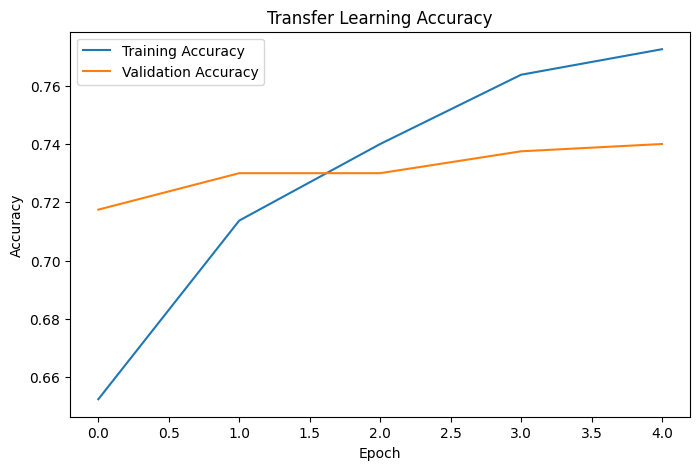

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Step 16: Plot Training and Validation Loss

Loss measures prediction error.

A decreasing loss usually means the model is improving.

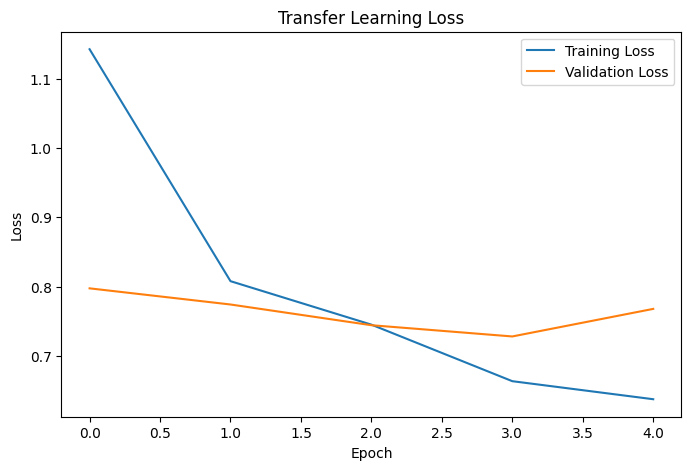

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Step 17: Generate Predictions

The model outputs probabilities for each lesion class.

The class with the highest probability is selected as the final prediction.

In [18]:
y_pred_probs = model.predict(X_val)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 756ms/step


## Step 18: Classification Report

The classification report shows:

- Precision
- Recall
- F1-score
- Support

These metrics are especially important in Medical AI because accuracy alone may not be enough.

In [19]:
print(
    classification_report(
        y_val,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       akiec       0.67      0.29      0.40        14
         bcc       0.25      0.05      0.09        19
         bkl       0.55      0.27      0.36        45
          df       0.00      0.00      0.00         6
         mel       0.62      0.29      0.39        45
          nv       0.77      0.99      0.86       267
        vasc       1.00      0.25      0.40         4

    accuracy                           0.74       400
   macro avg       0.55      0.31      0.36       400
weighted avg       0.69      0.74      0.68       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 19: Confusion Matrix

A confusion matrix shows where the model is making correct and incorrect predictions.

This helps identify which lesion classes are being confused.

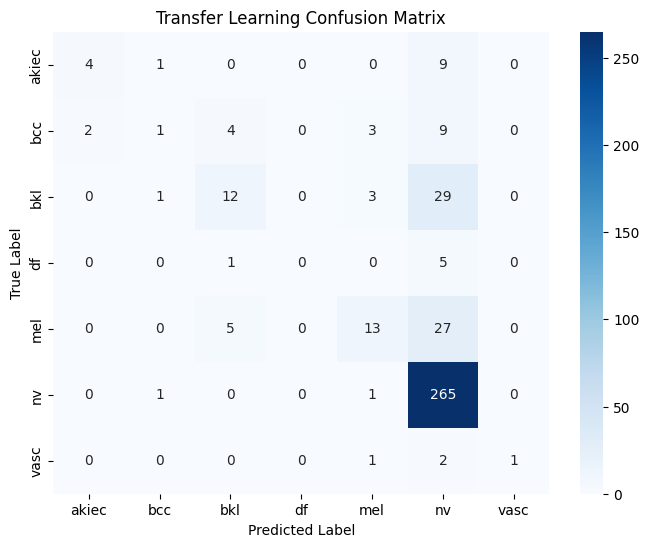

In [20]:
cm = confusion_matrix(
    y_val,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Transfer Learning Confusion Matrix")

plt.show()

## Step 20: Visualize Sample Predictions

Now we display validation images with their actual and predicted labels.

This helps us visually inspect model performance.

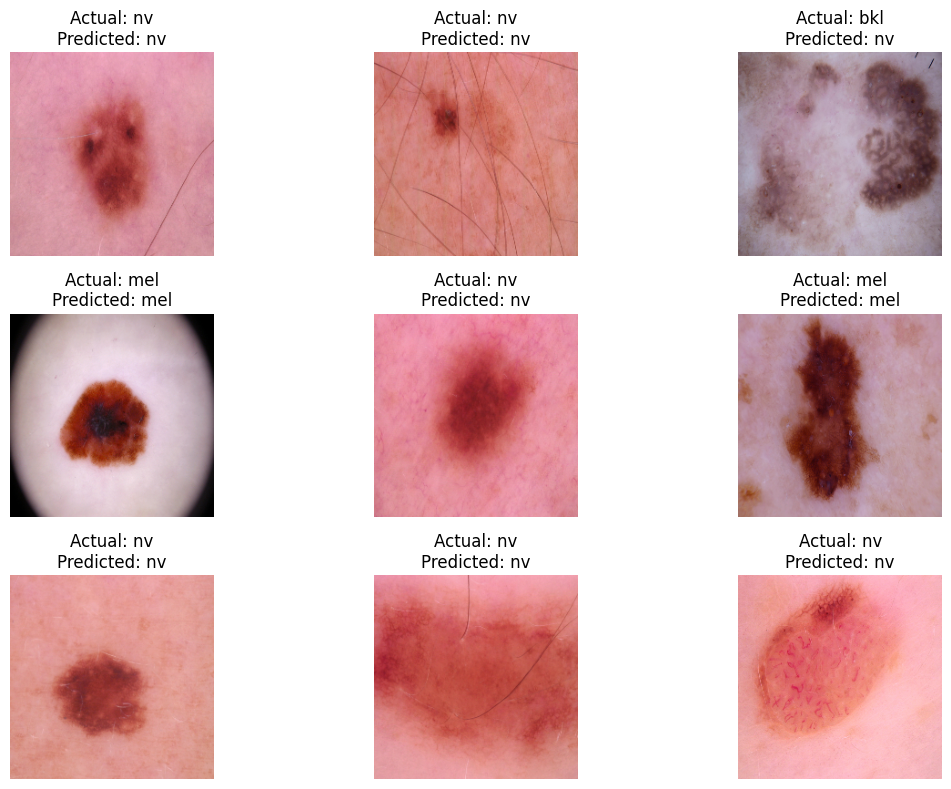

In [21]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    img = X_val[i]

    img_display = (img + 1) / 2

    actual = label_encoder.inverse_transform(
        [y_val[i]]
    )[0]

    predicted = label_encoder.inverse_transform(
        [y_pred[i]]
    )[0]

    plt.imshow(img_display)

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion

In this notebook, I built a transfer learning model for skin lesion classification using HAM10000 and MobileNetV2.

## What I Learned

- How to prepare HAM10000 images for transfer learning
- How to use MobileNetV2 as a pre-trained feature extractor
- How to freeze a base model
- How to add custom classification layers
- How to train a transfer learning model
- How to evaluate medical image classification performance
- Why transfer learning is useful for Medical AI and MobileSkinXAI

This notebook represents a realistic Medical AI workflow and is closely related to future skin cancer screening research.